In [26]:
import pandas as pd
import os
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction import text

## Nombre d'articles par publication (Utile pour définir certains indices)

In [2]:
# déterminé empiriquement
n_chunks = 269

In [3]:
num_articles = dict()
chunksize = 10000

reader = pd.read_csv('data/all-the-news-2-1.csv', chunksize=chunksize)

for chunk in tqdm(reader, total=n_chunks, desc="Avancement"):
    counts = chunk['publication'].value_counts()

    for pub, count in counts.items():
        num_articles[pub] = num_articles.get(pub, 0) + count

Avancement: 100%|██████████| 269/269 [02:20<00:00,  1.91it/s]


In [4]:
print(num_articles)

{'Reuters': 840094, 'Vox': 47272, 'Vice': 101137, 'TMZ': 49595, 'Vice News': 15539, 'Hyperallergic': 13551, 'Business Insider': 57953, 'TechCrunch': 52095, 'Axios': 47815, 'Refinery 29': 111433, 'The Verge': 52424, 'Mashable': 94107, 'People': 136488, 'Economist': 26227, 'CNN': 127602, 'Gizmodo': 27228, 'New Yorker': 4701, 'CNBC': 238096, 'Wired': 20243, 'New Republic': 11809, 'Fox News': 20144, 'The Hill': 208411, 'Politico': 46377, 'Buzzfeed News': 32819, 'The New York Times': 252259, 'Washington Post': 40882}


## Evaluate diversity in articles per publication

In [5]:
def lexical_diversity(text):
    tokens = text.lower().split()
    if len(tokens) == 0: return 0
    return len(set(tokens)) / len(tokens)

chunksize = 10000
diversity = dict()
max_iterations = 500  # nombre de chunks à lire

for chunk in tqdm(pd.read_csv('data/all-the-news-2-1.csv', chunksize=chunksize), total=n_chunks, desc='Avancement'):
    for row in chunk.itertuples():
        article = str(row.article)
        publication = row.publication
        if pd.isna(publication):
            continue
        
        diversity[publication]=diversity.get(publication, 0)+lexical_diversity(article)


Avancement: 100%|██████████| 269/269 [04:58<00:00,  1.11s/it]


In [6]:
# Convertir en liste si nécessaire
for key in diversity.keys():
    diversity[key]/=num_articles[key]


In [7]:
diversity_sorted = dict(sorted(diversity.items(), key=lambda x: x[1], reverse=True))
print(diversity_sorted)

{'Washington Post': 0.9732635328177068, 'TMZ': 0.7282242174995742, 'Refinery 29': 0.7166990538345723, 'Axios': 0.7075705969358183, 'Reuters': 0.6985472712517042, 'Wired': 0.6862388817574324, 'CNBC': 0.6320862895355701, 'Economist': 0.6315511635682558, 'Mashable': 0.6266464947279541, 'People': 0.6244127069412583, 'The Hill': 0.6194999670353234, 'Gizmodo': 0.6089499453080321, 'The Verge': 0.6036966073451976, 'Fox News': 0.5937949292917701, 'New Republic': 0.5930677587221502, 'Vice': 0.5878073826133338, 'TechCrunch': 0.5846138656199888, 'Buzzfeed News': 0.5816754174354597, 'Hyperallergic': 0.5782136424345414, 'CNN': 0.5721462813968434, 'Politico': 0.5701580889765296, 'New Yorker': 0.5628653315022772, 'The New York Times': 0.5589598339006094, 'Vox': 0.5291171347160225, 'Business Insider': 0.5231502013132169, 'Vice News': 0.44899618926296075}


## Graphe de similarité entre médias

In [8]:
# Dictionnaire pour stocker le texte accumulé
corpus_par_pub = {pub: "" for pub in num_articles.keys() if isinstance(pub, str)}
limit_chars = 500_000 # Ajustable selon ta RAM

print("Extraction du texte pour la similarité...")
reader = pd.read_csv('data/all-the-news-2-1.csv', chunksize=chunksize)

for chunk in tqdm(reader, total=n_chunks, desc="Chargement"):
    for row in chunk.itertuples():
        pub = row.publication
        if pd.isna(pub) or pub not in corpus_par_pub:
            continue
        
        # On n'ajoute du texte que si on n'a pas dépassé la limite
        if len(corpus_par_pub[pub]) < limit_chars:
            article_text = str(row.article)
            corpus_par_pub[pub] += " " + article_text

Extraction du texte pour la similarité...


Chargement:   0%|          | 0/269 [00:00<?, ?it/s]

Chargement: 100%|██████████| 269/269 [02:33<00:00,  1.75it/s]


In [9]:
# Transformation du dictionnaire en listes pour sklearn
labels = list(corpus_par_pub.keys())
documents = list(corpus_par_pub.values())

# Vectorisation TF-IDF (en retirant les mots vides anglais)
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = vectorizer.fit_transform(documents)

# Calcul de la matrice de similarité (Cosine Similarity)
# On obtient une matrice carrée où chaque cellule (i,j) est le score entre deux médias
sim_matrix = cosine_similarity(tfidf_matrix)

### Méthode 1 : Par seuillage

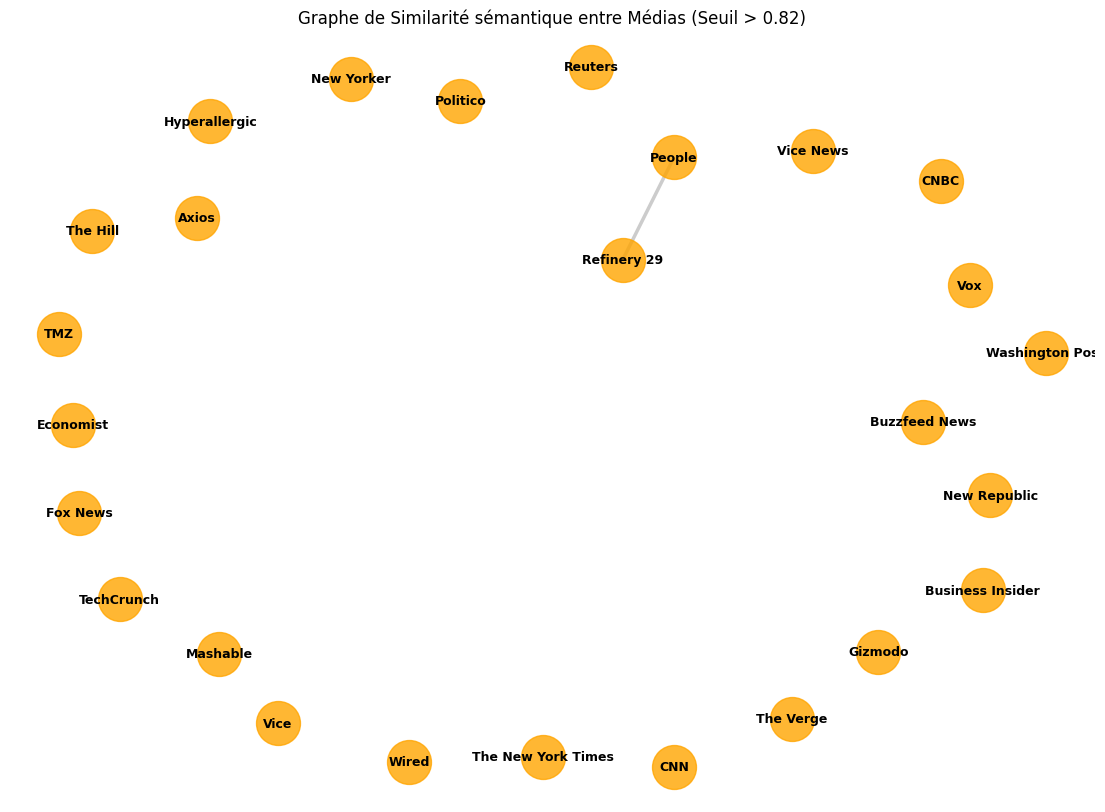

In [10]:
G = nx.Graph()

# Ajout des nœuds (les publications)
for pub in labels:
    G.add_node(pub)

# Ajout des arêtes (liens) si la similarité est forte
threshold = 0.82  
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        score = sim_matrix[i, j]
        if score > threshold:
            G.add_edge(labels[i], labels[j], weight=score)

# Visualisation
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.6, seed=42) # k contrôle l'espacement

# Dessin du réseau
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='orange', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Les arêtes sont plus épaisses si la similarité est forte
edges = G.edges(data=True)
weights = [d['weight'] * 3 for u, v, d in edges]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.4)

plt.title(f"Graphe de Similarité sémantique entre Médias (Seuil > {threshold})")
plt.axis('off')
plt.show()

Seuil beaucoup trop haut, on ne voit qu'un lien très fort entre People et Refinery.

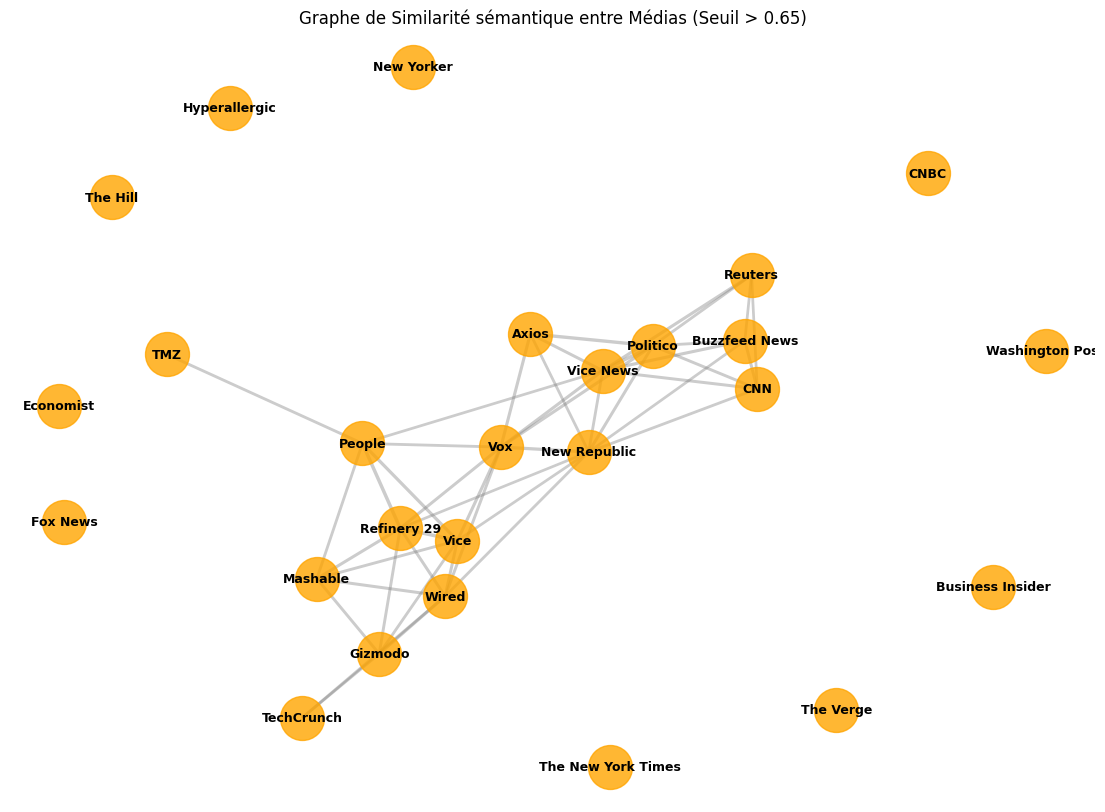

In [11]:
G = nx.Graph()

# Ajout des nœuds (les publications)
for pub in labels:
    G.add_node(pub)

# Ajout des arêtes (liens) si la similarité est forte
threshold = 0.65  
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        score = sim_matrix[i, j]
        if score > threshold:
            G.add_edge(labels[i], labels[j], weight=score)

# Visualisation
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.6, seed=42) # k contrôle l'espacement

# Dessin du réseau
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='orange', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Les arêtes sont plus épaisses si la similarité est forte
edges = G.edges(data=True)
weights = [d['weight'] * 3 for u, v, d in edges]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.4)

plt.title(f"Graphe de Similarité sémantique entre Médias (Seuil > {threshold})")
plt.axis('off')
plt.show()

**COMMENTAIRES :**
On voit un cluster central avec énormément de connections.
- *Partie haute :* **La partie politique.**\
    Il regroupe *Reuters, CNN, Politico, Buzzfeed News et New Republic*. Ces médias traitent de l'actualité avec un vocabulaire standardisé.
- *Partie gauche :* **Divertissement/Lifestyle.**\
    Il regroupe *People, Refinery 29 et TMZ*. On note que People est placé dans un endroit qui sert de pont entre divertissement et le reste du réseau.
- *Partie basse :* **Tech.**\
    Il regroupe *Gizmodo, Wired et TechCrunch.*

Concernant les Isolés à ce seuil, on trouve *The New York Times, The Verge, ou Fox News*. Cela suggère soit un vocabulaire très spécifique, soit un format d'article (longueur style) qui est très différent de la moyenne des autres médias.

### Méthode 2 : Par utilisation de KNN

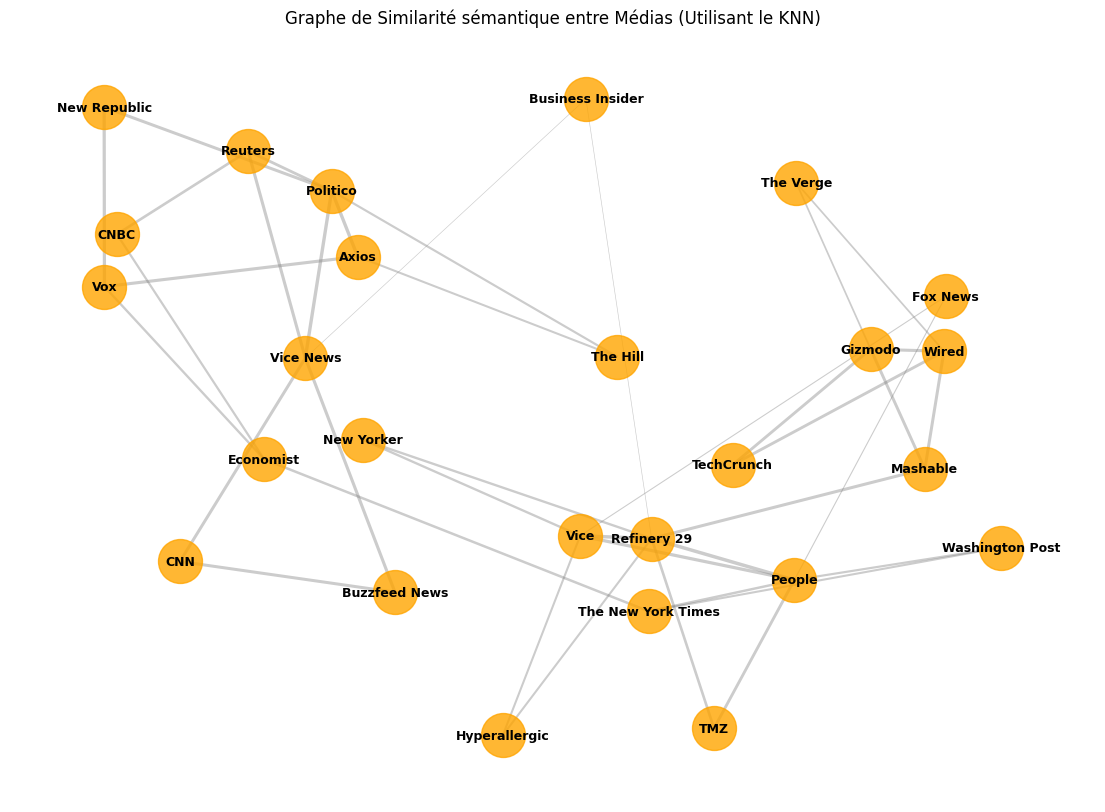

In [12]:
G = nx.Graph()
k = 2 # Chaque média sera lié à ses 2 voisins les plus proches

for i, pub_i in enumerate(labels):
    # On récupère les scores de similarité pour le média i
    scores = sim_matrix[i]
    
    # On trie les indices par score décroissant et on prend les k+1 premiers 
    # (le premier est toujours le média lui-même, donc on l'ignore avec [1:k+1])
    closest_indices = scores.argsort()[-(k+1):-1]
    
    for idx in closest_indices:
        G.add_edge(pub_i, labels[idx], weight=scores[idx])


# Visualisation
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.6, seed=42) # k contrôle l'espacement

# Dessin du réseau
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='orange', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Les arêtes sont plus épaisses si la similarité est forte
edges = G.edges(data=True)
weights = [d['weight'] * 3 for u, v, d in edges]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.4)

plt.title(f"Graphe de Similarité sémantique entre Médias (Utilisant le KNN)")
plt.axis('off')
plt.show()

Le graphe KNN révèle des "ponts" (Bridges) :

- *The Hill* agit comme un pont entre les médias très orientés business/news et le reste du réseau.

- *The New York Times* et *The Washington Post*, bien qu'influents, ont des signatures lexicales assez uniques qui les placent souvent en périphérie ou connectés à des pôles spécifiques, ce qui montre une identité éditoriale forte.

### Création de communautés de média (Modèle primitif nul "gougougaga")

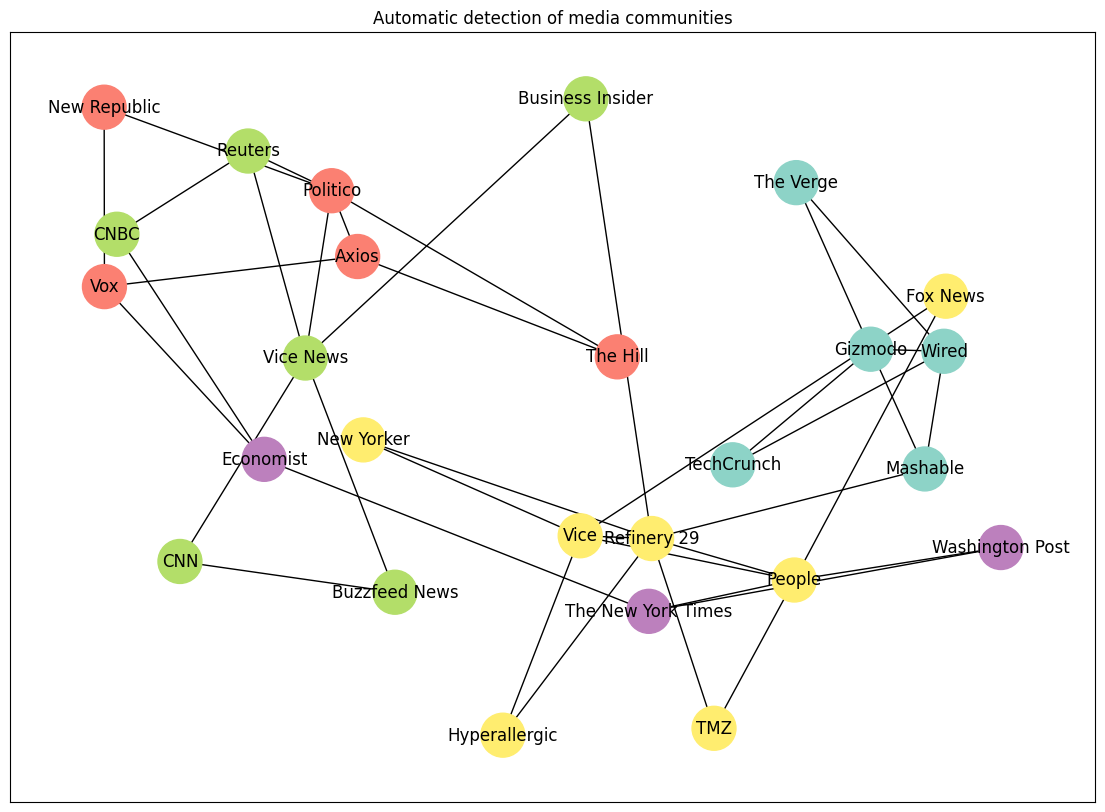

In [13]:
import community.community_louvain as community_louvain # pip install python-louvain

# Trouver les communautés
partition = community_louvain.best_partition(G)

# Colorer les nœuds selon leur communauté
values = [partition.get(node) for node in G.nodes()]

plt.figure(figsize=(14, 10))
nx.draw_networkx(G, pos, node_color=values, cmap=plt.cm.Set3, node_size=1000)
plt.title("Automatic detection of media communities")
plt.show()

**/!\\ Les couleurs peuvent changer après compilation, mais les clusters restent les mêmes.**

Analyse des clusters :
- Cluster Bleue : *The Verge, Wired, Gizmodo, Mashable et TechCrunch*. C'est le cluster Tech/Digital. Ils partagent un vocabulaire technique et thématique spécifique.
- Cluster Vert et Rouge : comme *Reuters, Axios, Politico et New Republic.* C'est le cluster News/Politique.
- Cluster Jaune : comme *Vice, Refinery 29, People, et TMZ*, c'est la section Divertissement/Culture/Société.
- Cluster Mauve : *Economist, The New York Times, Washington Post* qui sont ensemble. C'est la "Presse de référence". Ils sont regroupés car ils ont des formats d'articles plus longs, un vocabulaire plus riche et couvrent tous les sujets (ce qui les rend "moyens" par rapport aux autres clusters spécialisés).

Il y a présence de ponts dans ce graphe, tels que *The Hill* ou *Vice News*, à l'intersection de plusieurs groupes.

### Meilleur modèle + Mots clés par communauté

--- ANALYSE DES COMMUNAUTÉS ET MOTS-CLÉS ---

COMMUNAUTÉ 0 (4 médias) :
Médias : Reuters, Economist, Business Insider, CNBC
Mots-clés : navigation, indicates, inbox daily, menu, editing, stocks, cnbc, cramer, dispatch, eu, inbox, inflation

COMMUNAUTÉ 1 (5 médias) :
Médias : Politico, Vice News, Vox, Axios, The Hill
Mots-clés : obamacare, 628, 202, vice news, president donald, axios, trump administration, medicaid, mueller, politico, street nw, 900 washington

COMMUNAUTÉ 2 (6 médias) :
Médias : Vice, TMZ, People, Refinery 29, Fox News, Washington Post
Mots-clés : tmz, apos, kardashian, ct, apost, innings, ballroom, chyna, cops, bowie, ufc, rd

COMMUNAUTÉ 3 (6 médias) :
Médias : Hyperallergic, The New York Times, New Yorker, New Republic, CNN, Buzzfeed News
Mots-clés : buzzfeed news, rubio, museum, marcia, buzzfeed, nectar, exhibition, nimr, broadway, caucuses, carson, patton

COMMUNAUTÉ 4 (5 médias) :
Médias : Gizmodo, TechCrunch, Wired, The Verge, Mashable
Mots-clés : ces, twitter com

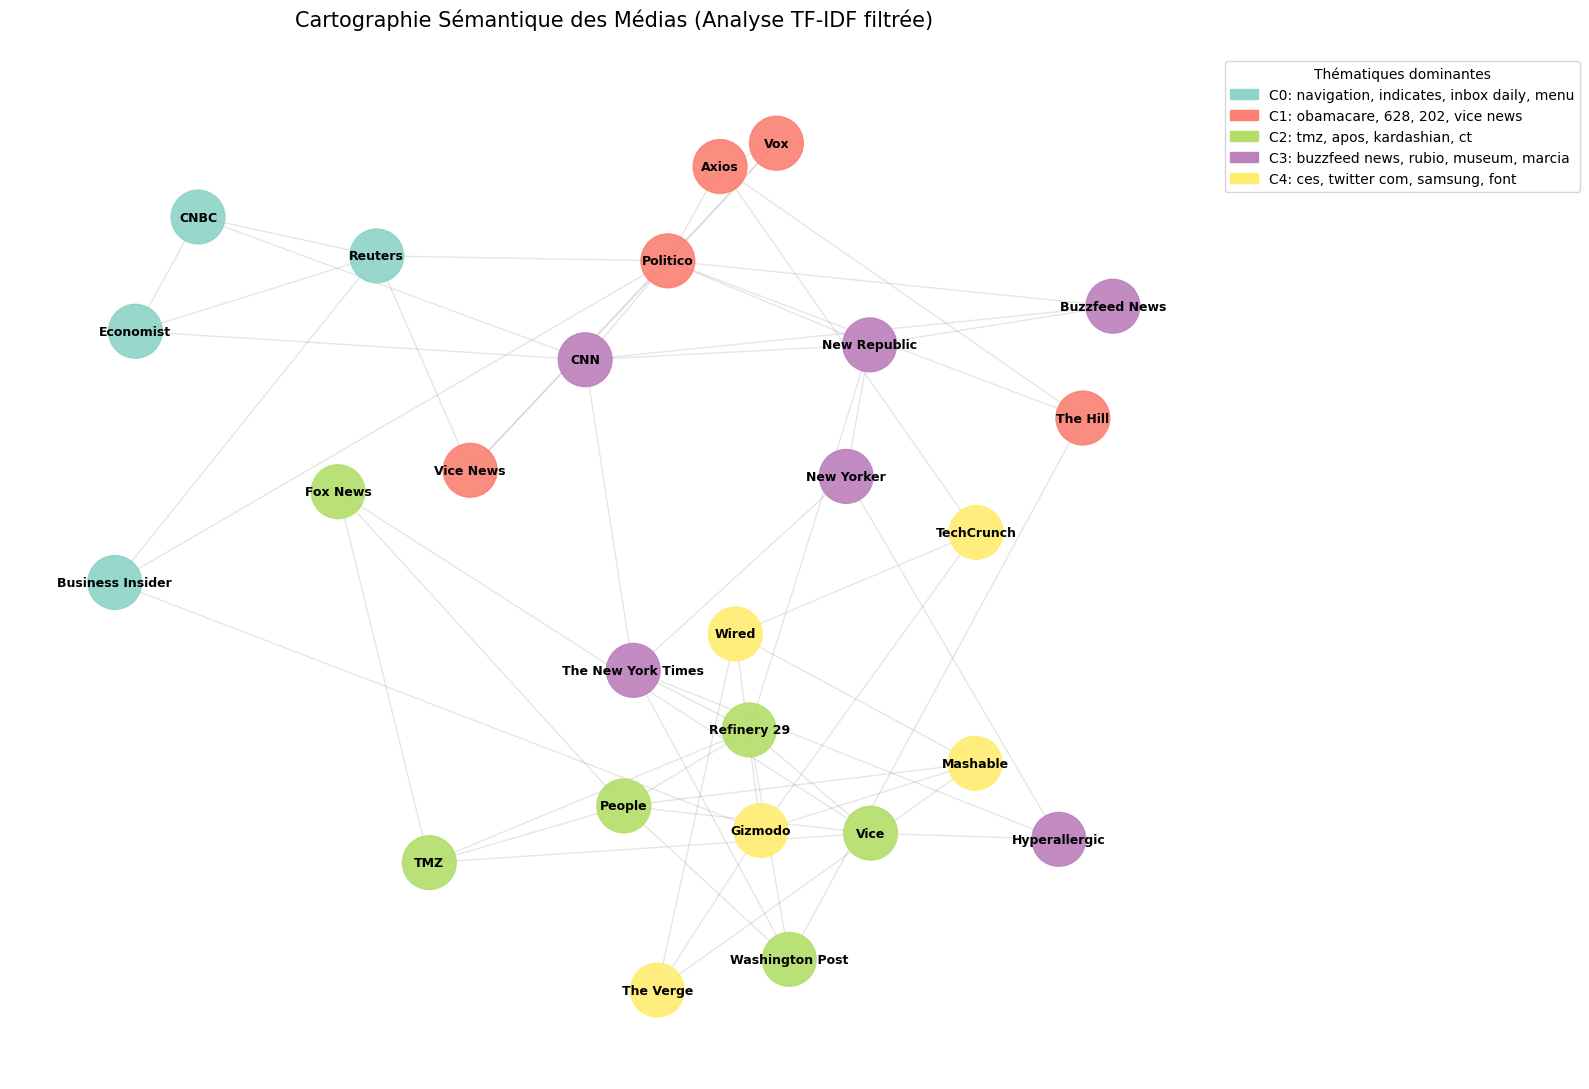

In [ ]:
news_noise = [
    'said', 'mr', 'mrs', 'ms', 'says', 'told', 'just', 'like', 'new', 'year', 
    'people', 'time', 'nan', 'aposs', 'expandable', 'chevron', '000', 'don', 't',
    's', 'u', 'it', 'the', 'day', 'week', 'month', 'years'
]
base_stop_words = text.ENGLISH_STOP_WORDS.union(news_noise)

# On utilise max_df=0.6 pour supprimer les mots trop communs entre les médias
vectorizer = TfidfVectorizer(
    stop_words=list(base_stop_words),
    max_features=10000,
    ngram_range=(1, 2), # Pour attraper "white house", "silicon valley", etc.
    max_df=0.6,         # INDISPENSABLE : ignore ce qui est trop commun
    min_df=2            # Ignore ce qui est trop rare (bruit)
)

# On transforme notre corpus (on s'assure que labels et documents sont synchronisés)
labels = list(corpus_par_pub.keys())
documents = list(corpus_par_pub.values())
tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

# Graph creation
sim_matrix = cosine_similarity(tfidf_matrix)
G = nx.Graph()
k = 3 # Nombre de voisins proches par média

for i, pub_i in enumerate(labels):
    # On prend les indices des k+1 plus grandes similarités (on s'exclut soi-même)
    closest_indices = sim_matrix[i].argsort()[-(k+1):-1]
    for idx in closest_indices:
        G.add_edge(pub_i, labels[idx], weight=sim_matrix[i, idx])

# 4. DÉTECTION DES COMMUNAUTÉS
partition = community_louvain.best_partition(G)

# 5. EXTRACTION PROPRE DES MOTS-CLÉS PAR COMMUNAUTÉ
community_info = {}
unique_communities = sorted(set(partition.values()))

print("--- ANALYSE DES COMMUNAUTÉS ET MOTS-CLÉS ---")
for comm_id in unique_communities:
    # Récupérer les médias du groupe
    members = [node for node, c in partition.items() if c == comm_id]
    member_indices = [labels.index(m) for m in members]
    
    # Calculer le score TF-IDF moyen pour ce groupe
    group_tfidf_mean = tfidf_matrix[member_indices].mean(axis=0).A1
    
    # Sortir les 12 meilleurs mots-clés
    top_ids = group_tfidf_mean.argsort()[-12:][::-1]
    top_keywords = [feature_names[i] for i in top_ids]
    
    # Stockage pour le graphe
    community_info[comm_id] = {
        'members': members,
        'keywords': top_keywords,
        'label': f"Groupe {comm_id}: {', '.join(top_keywords[:3])}..."
    }
    
    print(f"\nCOMMUNAUTÉ {comm_id} ({len(members)} médias) :")
    print(f"Médias : {', '.join(members)}")
    print(f"Mots-clés : {', '.join(top_keywords)}")

# 6. VISUALISATION FINALE AVEC LÉGENDE
plt.figure(figsize=(16, 11))
pos = nx.spring_layout(G, k=0.6, seed=42)

# Couleur des nœuds
colors = [partition[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.Set3, node_size=1500, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Création d'une légende propre
import matplotlib.patches as mpatches
legend_handles = []
for comm_id in unique_communities:
    color = plt.cm.Set3(comm_id / (max(unique_communities) if max(unique_communities) > 0 else 1))
    # On utilise les 3 premiers mots-clés pour la légende
    label_text = f"C{comm_id}: {', '.join(community_info[comm_id]['keywords'][:4])}"
    legend_handles.append(mpatches.Patch(color=color, label=label_text))

plt.legend(handles=legend_handles, title="Thématiques dominantes", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.title("Cartographie Sémantique des Médias (Analyse TF-IDF filtrée)", fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

- **Communauté 0 (Économie & Marchés) :** On y trouve *Reuters, Economist, CNBC*. Les mots-clés comme stocks, inflation, eu, editing et Cramer (célèbre présentateur financier) confirment un pôle dédié à la finance et à l'actualité institutionnelle.

- **Communauté 1 (Politique américaine) :** Ce groupe regroupe *Politico, Axios, The Hill*. C'est le cœur du journalisme de pouvoir. Les termes Obamacare, Mueller, Medicaid et Trump Administration sont des marqueurs clairs de la politique intérieure américaine.

- **Communauté 2 (Pop Culture & Célébrités) :** *TMZ, People, Refinery 29*. Les mots-clés Kardashian, Chyna, cops et ballroom montrent un traitement axé sur le divertissement et les faits divers.

    **Note :** La présence du Washington Post et de Fox News ici peut s'expliquer par un échantillon de texte (500k caractères) qui a peut-être capturé une section "Lifestyle" ou "Entertainment" très dense au moment de l'extraction.

- **Communauté 3 (Culture, Arts & Long-form) :** Le regroupement *Hyperallergic, The New Yorker, NYT* est très cohérent. Les mots museum, exhibition, Broadway indiquent un pôle culturel et intellectuel.

- **Communauté 4 (Tech & Hardware) :** C'est le cluster le plus pur. *Gizmodo, TechCrunch, Wired, The Verge*. Les termes CES, Samsung, battery, startup et les liens Twitter/HTTPS sont typiques du journalisme technologique qui partage beaucoup de liens et de fiches techniques.